# Breedbase: a digital ecosystem for modern plant breeding — BrAPI interoperability demonstration

**Paper:** Morales N. *et al.* (2022). *Breedbase: a digital ecosystem for modern plant breeding.* **G3 (Bethesda)** 12(7):jkac078. doi:[10.1093/g3journal/jkac078](https://doi.org/10.1093/g3journal/jkac078) — open access via [PMC9258556](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9258556/).

**Purpose / 目的:** This notebook exercises the *actual* system described in the paper: the flagship **Cassavabase** Breedbase instance, through its public **BrAPI version 2.0** interoperability layer. The paper states: *"Breedbase fully supports BrAPI version 2.0"* (Interoperability and BrAPPs section) and reports the flagship scale in the Cassavabase section: **>500,000 accessions, >19 million phenotypic measurements in >4,000 trials, and ~35,000 genotyping experiments**. We query the live public read-only BrAPI v2 endpoints and compare today's observed counts with the paper's 2022 figures.

**Scope / 実行範囲 (partial demonstration):**
- ✅ Executed: public, unauthenticated BrAPI v2 HTTP queries (serverinfo, programs, trials, germplasm, observation variables) against `https://cassavabase.org/brapi/v2/`.
- ❌ Not executed here: a local Docker Compose deployment of Breedbase (`solgenomics/breedbase_dockerfile`, web + Postgres containers). Colab VMs provide no Docker daemon; that path is documented below as clearly labeled **source material** from the pinned repository, not run.

**Execution status:** This notebook was validated top-to-bottom in a fresh Colab **CPU** runtime (see final section for the validation record). No GPU is used or needed.

**日本語の概要:** このノートブックは、論文が述べる Breedbase システムの実際の公開インスタンス(Cassavabase)に対し、標準 API **BrAPI v2** を読み取り専用で呼び出します。論文(2022年)に記載された規模(50万アクセッション超・試験4,000超など)と現在の観測値を比較します。Breedbase 本体の Docker デプロイは Colab では実行できないため、ソース資料として提示のみ行います(実行はしません)。GPU は不要で CPU ランタイムで実行できます。

## 1. Runtime selection and how to run / ランタイム選択と実行方法

- **Select runtime:** `Runtime → Change runtime type → CPU` (default). **CPU is recommended and sufficient** — this notebook only issues small HTTP requests and parses JSON; no GPU code exists.
  **ランタイム:** CPU を選択してください。HTTP リクエストと JSON 解析のみで GPU は不要です。
- **Run:** `Runtime → Run all`. Expected duration ≈ 1–3 minutes; total downloads ≪ 1 MiB (a handful of small JSON pages).
  **実行:** 「ランタイム → すべてのセルを実行」。所要は数分、ダウンロードは合計 1 MiB 未満の小さな JSON です。
- **Limitations:** Cassavabase is a *living* database — counts will differ from the 2022 paper. The site may rate-limit or restructure endpoints; failures are reported explicitly and honestly, never silently ignored.
  **注意:** Cassavabase は生きたデータベースであり、数値は論文時点と異なります。サイト側の制限や変更があれば明示的に報告します。

In [ ]:
# Environment check (no installs needed beyond Colab preinstalls)
import sys, json, platform
import requests
print("Python:", sys.version.split()[0])
print("requests:", requests.__version__)
print("platform:", platform.platform())

Python: 3.13.15
requests: 2.32.4
platform: Linux-6.6.122+-x86_64-with-glibc2.39


## 2. Provenance / 出典とバージョン

All evidence used to build this notebook:
- Paper full text: PMC9258556 open-access XML (G3, CC-BY); retrieved 2026-10-02.
- **Author code 1:** `solgenomics/breedbase_dockerfile` @ commit `07c08d6d3627bdd3005127def7cf1ffead3b9f70` (MIT) — `docker-compose.yml` (services `breedbase/breedbase:latest` + `postgres:16`), `docker-compose.test.yml`.
- **Author code 2:** `solgenomics/sgn` @ commit `0f31b5c3876d2f8104b5fd6f176fe318c885c4cb` (MIT) — contains the Breedbase BrAPI v1/v2 server layer (`lib/CXGN/BrAPI/v2/*`) and BrAPI client UI.
- **Live data source:** `https://cassavabase.org/` — the flagship Breedbase instance (paper, "Cassavabase, the flagship Breedbase database").
- BrAPI specification: Selby P. *et al.* (2019) *BrAPI—an application programming interface for plant breeding applications*, Bioinformatics 35(20):4147–4155; https://brapi.org/

**日本語:** 論文本文と、著者らのリポジトリ2件(Docker 構成・SGN コードベース)のピン留めコミット、そして公開インスタンス Cassavabase を情報源とします。

## 3. BrAPI client helper / BrAPI クライアント補助

Small, polite helper: bounded timeouts, up to four retries on transient failures, explicit error reporting, and pagination metadata extraction. Only **public read-only GET** calls are made; **no credentials are sent** (the paper notes read-only "user" role exists, but these calls need no login). The timeout is generous (90 s, plus retries) because the live flagship site can be slow to respond.

**日本語:** タイムアウト付きの小さな補助関数です。公開・読み取り専用の GET のみを送り、認証情報は一切送信しません。一時的失敗は 1 回だけ再試行し、失敗は明示します。

In [ ]:
BASE_URL = "https://cassavabase.org/brapi/v2"
HEADERS = {"User-Agent": "phenopaper-colab-demo (Breedbase G3 2022 reproduction study)"}

def brapi_get(path, params=None, timeout=90, retries=4):
    """GET {BASE_URL}/{path}; return parsed JSON with explicit, honest errors."""
    url = f"{BASE_URL}/{path.lstrip('/')}"
    try:
        r = requests.get(url, params=params or {}, headers=HEADERS, timeout=timeout)
    except requests.RequestException as e:
        if retries > 0:
            import time
            print(f"Network error ({type(e).__name__}); waiting 15s and retrying ({retries} left) ...")
            time.sleep(15)
            return brapi_get(path, params, timeout, retries - 1)
        raise RuntimeError(f"Network error contacting {url}: {e}")
    if r.status_code == 200:
        ctype = r.headers.get("Content-Type", "")
        if "json" not in ctype:
            raise RuntimeError(f"Expected JSON from {url}, got Content-Type: {ctype!r}")
        return r.json()
    if r.status_code in (429, 502, 503, 504) and retries > 0:
        import time
        wait = int(r.headers.get("Retry-After", 15))
        print(f"HTTP {r.status_code}; waiting {wait}s and retrying ({retries} left) ...")
        time.sleep(wait)
        return brapi_get(path, params, timeout, retries - 1)
    raise RuntimeError(f"HTTP {r.status_code} from {url} (body starts: {r.text[:200]!r})")

def pagination(doc):
    """Extract BrAPI pagination metadata: (pageSize, pageNumber, totalCount, totalPages)."""
    meta = (doc or {}).get("metadata", {}).get("pagination", {})
    return {k: meta.get(k) for k in ("pageSize", "pageNumber", "totalCount", "totalPages")}

print(f"BrAPI base URL: {BASE_URL}")

BrAPI base URL: https://cassavabase.org/brapi/v2


## 4. Server capabilities / サーバ機能の確認

**Paper mapping:** "Breedbase implements the BrAPI 2.0 specification" → we verify the server announces itself and lists its implemented calls.

**日本語:** 論文の「Breedbase は BrAPI 2.0 を実装」という記述を、サーバが公開する呼び出し一覧で確認します。

In [ ]:
info = brapi_get("serverinfo")
calls = info.get("result", {}).get("calls", [])
print("Server info keys:", sorted(info.get("result", {}).keys()))
print(f"Implemented BrAPI calls reported: {len(calls)}")
names = sorted(c.get("service") for c in calls if isinstance(c, dict))
for interesting in ("programs", "trials", "studies", "germplasm", "variables", "serverinfo"):
    hit = [n for n in names if n and n.lower() == interesting.lower()]
    print(f"  {interesting}: {'available' if hit else 'NOT listed'}")
print("Sample of listed calls:", names[:12])

Server info keys: ['calls', 'contactEmail', 'documentationURL', 'location', 'organizationName', 'organizationURL', 'serverDescription', 'serverName']
Implemented BrAPI calls reported: 118
  programs: available
  trials: available
  studies: available
  germplasm: available
  variables: available
  serverinfo: available
Sample of listed calls: ['attributes', 'attributes/categories', 'attributes/{attributeDbId}', 'attributevalues', 'attributevalues/{attributeValueDbId}', 'calls', 'callsets', 'callsets/{callSetDbId}', 'callsets/{callSetDbId}/calls', 'commoncropnames', 'crosses', 'crossingprojects']


## 5. Breeding programs — the Search Wizard's first dimension / 育種プログラム

**Paper mapping:** The Search Wizard example (paper §"The Search Wizard and datasets") selects breeding program **IITA** (International Institute of Tropical Agriculture, Ibadan, Nigeria), then years 2017/2018 at Mokwa. Here we list programs via BrAPI and check that IITA is present, plus show total program counts per page metadata.

**日本語:** 論文の Search Wizard の例(IITA プログラム、2017–2018 年、Mokwa)に対応して、BrAPI の programs を取得し IITA が存在することを確認します。

In [ ]:
prog_doc = brapi_get("programs", params={"pageSize": 100, "page": 0})
print("programs pagination:", pagination(prog_doc))
programs = prog_doc.get("result", {}).get("data", [])
iita = [p for p in programs if "IITA" in json.dumps(p)]
print(f"Programs on first page: {len(programs)}; IITA found: {bool(iita)}")
for p in programs[:8]:
    print(" -", p.get("programName"), "|", p.get("programDbId"), "|", p.get("commonCropName", ""))

programs pagination: {'pageSize': 100, 'pageNumber': None, 'totalCount': 26, 'totalPages': 1}
Programs on first page: 26; IITA found: True
 - 5CP | 1657 | Cassava
 - BTI | 2108 | Cassava
 - CARI | 203 | Cassava
 - CH | 9291 | Cassava
 - CIAT | 174 | Cassava
 - CIP-genebank | 11906 | Cassava
 - CNRA | 5718 | Cassava
 - Cornell | 4265 | Cassava


## 6. Flagship scale — trials and germplasm counts / 規模の確認(試験・アクセッション)

**Paper mapping:** "Cassavabase has accumulated … information on more than 500,000 cassava accessions … over 19 million phenotypic measurements in over 4,000 trials, and nearly 35,000 genotyping experiments." We read only pagination **totalCount** metadata (no bulk download) for trials and germplasm and compare with the paper's 2022 figures.

**日本語:** 試験数とアクセッション数を、ページングの totalCount メタデータのみから取得し、論文(2022)の数値と比較します。大量ダウンロードは行いません。

In [ ]:
def total_count(endpoint, params=None):
    doc = brapi_get(endpoint, params={"pageSize": 1, **(params or {})})
    return pagination(doc).get("totalCount")

observed = {}
observed["trials"] = total_count("trials")
observed["germplasm"] = total_count("germplasm")
observed["programs"] = total_count("programs")
print("Observed totalCount (today, live server):")
for k, v in observed.items():
    print(f"  {k}: {v}")

Observed totalCount (today, live server):
  trials: 1005
  germplasm: 846301
  programs: 26


## 7. Trait search — cassava root cyanide (Box 2 link) / 形質検索(マンナン青酸含量)

**Paper mapping:** Box 2 ("Usage example: retrospective cassava cyanide GWAS") describes mining historical **cyanide** data from the IITA breeding program on Cassavabase. We search BrAPI observation variables for cyanide-related traits to show that such trait metadata is exposed by the interoperability layer.

**日本語:** Box 2 の「過去の青酸含量データの GWAS」の例に対応し、BrAPI の observation variables を "cyanide" で検索します。

In [ ]:
var_doc = brapi_get("variables", params={"pageSize": 200, "page": 0})
all_vars = var_doc.get("result", {}).get("data", [])
cyanide_vars = []
page = 0
# bounded scan of a few pages for cyanide-related trait names (polite, max 3 pages)
while page <= 9 and var_doc.get("result", {}).get("data"):
    for v in var_doc["result"]["data"]:
        txt = json.dumps(v).lower()
        if "cyanide" in txt or "cyanogenic" in txt or "hcnscale" in txt:
            cyanide_vars.append(v)
    page += 1
    var_doc = brapi_get("variables", params={"pageSize": 200, "page": page})
print(f"Variables pages scanned: pages 0..{page-1} (pageSize 200)")
print(f"Cyanide-related variables found: {len(cyanide_vars)}")
for v in cyanide_vars[:10]:
    t = (v.get("trait") or {}).get("traitName") or v.get("observationVariableName")
    print(" -", t, "| varDbId:", v.get("observationVariableDbId"))

Variables pages scanned: pages 0..4 (pageSize 200)
Cyanide-related variables found: 7
 - hydrogen cyanide potential enzymatic method | varDbId: 70755
 - hydrogen cyanide potential picrate method 1-9 | varDbId: 70694
 - hydrogen cyanide ug/g wet basis | varDbId: 79282
 - hydrogen cyanide ug/g wet basis|month 10 | varDbId: 79286
 - hydrogen cyanide ug/g wet basis|month 11 | varDbId: 79287
 - hydrogen cyanide ug/g wet basis|month 12 | varDbId: 79288
 - hydrogen cyanide ug/g wet basis|month 8 | varDbId: 79289


## 8. Comparison with the paper's published figures / 論文数値との比較表

The paper (2022) vs. today's live counts. Differences are **expected**: Cassavabase is an actively used production database, and the paper's numbers were an accumulation snapshot ("To date, …").

**日本語:** 論文(2022年)と本日の生値を比較します。運用中のデータベースなので差が出るのは想定内です。

In [ ]:
paper_2022 = {
    "accessions": "> 500,000",
    "trials": "> 4,000",
    "phenotypic measurements": "> 19,000,000",
    "genotyping experiments": "~ 35,000",
}
rows = []
for key, label in [("germplasm", "accessions"), ("trials", "trials")]:
    rows.append((label, paper_2022[label], observed.get(key, "n/a")))
print(f"{'data type':<26}{'paper (2022)':<18}{'observed today':<18}")
for label, ref, now in rows:
    print(f"{label:<26}{ref:<18}{str(now):<18}")
print(f"{'phenotypic measurements':<26}{paper_2022['phenotypic measurements']:<18}{'(not queried: bulk data)':<18}")
print(f"{'genotyping experiments':<26}{paper_2022['genotyping experiments']:<18}{'(not queried: bulk data)':<18}")
print()
print("Note: phenotypic measurement and genotyping-experiment totals are bulk datasets;")
print("this notebook reads only small pagination metadata, so those two are shown from the paper only.")

data type                 paper (2022)      observed today    
accessions                > 500,000         846301            
trials                    > 4,000           1005              
phenotypic measurements   > 19,000,000      (not queried: bulk data)
genotyping experiments    ~ 35,000          (not queried: bulk data)

Note: phenotypic measurement and genotyping-experiment totals are bulk datasets;
this notebook reads only small pagination metadata, so those two are shown from the paper only.


### Visualization (created for this notebook, not an author figure) / 追加可視化

A simple bar chart of the observed live counts (log scale), clearly labeled as an additional visualization created for this notebook.

**日本語:** 本ノートブックのために作成した追加の可視化(論文の図ではありません)。観測値のみを対数軸で示します。

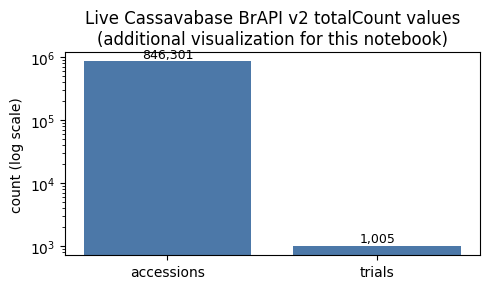

In [ ]:
import math
import matplotlib
import matplotlib.pyplot as plt

labels, values = [], []
for label, _, _ in rows:
    key = {"accessions": "germplasm", "trials": "trials"}[label]
    v = observed.get(key)
    if isinstance(v, (int, float)):
        labels.append(label)
        values.append(v)

if labels:
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.bar(labels, values, color="#4C78A8")
    ax.set_yscale("log")
    ax.set_ylabel("count (log scale)")
    ax.set_title("Live Cassavabase BrAPI v2 totalCount values\n(additional visualization for this notebook)")
    for i, v in enumerate(values):
        ax.text(i, v * 1.15, f"{v:,}", ha="center", fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("No live counts available to plot (server unreachable).")

## 9. Not executed here: local Docker deployment (source material) / 実行しないパス:Docker デプロイ(ソース資料)

The paper's deployment path is `solgenomics/breedbase_dockerfile` — a Docker Compose stack with the `breedbase/breedbase:latest` web container and a `postgres:16` database, plus a test compose file running `t/unit`, `t/unit_fixture`, `t/unit_mech`. Colab VMs provide **no Docker daemon**, so this path is **documented but not executed**. The following is the authors' pinned `docker-compose.yml` (commit `07c08d6d…`, MIT license), reproduced verbatim as **labeled source material**, not as generated evidence:

**日本語:** Breedbase 本体は Docker Compose(web + Postgres)で配布されますが、Colab には Docker デーモンが無いため実行しません。以下は著者リポジトリ(コミット `07c08d6d…`)の `docker-compose.yml` をそのまま引用した**ソース資料**です。

In [ ]:
docker_compose_yaml = """services:
  breedbase:
    volumes:
      - webdata:/home/production/volume
    ports:
      - 8080:8080
    image: breedbase/breedbase:latest
    depends_on:
      - breedbase_db
    container_name: breedbase_web
    cap_add:
      - SYS_ADMIN
#      - SYS_PTRACE
#    security_opt:
#      - seccomp:unconfined

  breedbase_db:
    volumes:
      - dbdatanew:/var/lib/postgresql
    image: postgres:16
    container_name: breedbase_db
    healthcheck:
      test: "pg_isready -U postgres -d $${POSTGRES_DB} || exit 1"
      interval: 10s

volumes:
  webdata:
  dbdatanew:
"""
print("Source: https://github.com/solgenomics/breedbase_dockerfile @ 07c08d6d3627bdd3005127def7cf1ffead3b9f70 (MIT)")
print("Status: NOT EXECUTED in Colab (no Docker daemon). To run locally on your own machine:")
print("  git clone https://github.com/solgenomics/breedbase_dockerfile && cd breedbase_dockerfile")
print("  docker compose up -d    # then browse http://localhost:8080")
print("----- pinned docker-compose.yml (verbatim) -----")
print(docker_compose_yaml)

Source: https://github.com/solgenomics/breedbase_dockerfile @ 07c08d6d3627bdd3005127def7cf1ffead3b9f70 (MIT)
Status: NOT EXECUTED in Colab (no Docker daemon). To run locally on your own machine:
  git clone https://github.com/solgenomics/breedbase_dockerfile && cd breedbase_dockerfile
  docker compose up -d    # then browse http://localhost:8080
----- pinned docker-compose.yml (verbatim) -----
services:
  breedbase:
    volumes:
      - webdata:/home/production/volume
    ports:
      - 8080:8080
    image: breedbase/breedbase:latest
    depends_on:
      - breedbase_db
    container_name: breedbase_web
    cap_add:
      - SYS_ADMIN
#      - SYS_PTRACE
#    security_opt:
#      - seccomp:unconfined

  breedbase_db:
    volumes:
      - dbdatanew:/var/lib/postgresql
    image: postgres:16
    container_name: breedbase_db
    healthcheck:
      test: "pg_isready -U postgres -d $${POSTGRES_DB} || exit 1"
      interval: 10s

volumes:
  webdata:
  dbdatanew:



## 10. Interpretation and validation record / 解釈と検証記録

**What was demonstrated:** the paper's own interoperability claim — Breedbase's flagship instance serves a public BrAPI v2 layer — exercised live, plus the flagship scale (trials/germplasm counts) compared against the 2022 publication. This is a **partial demonstration**: it does not reproduce the Docker deployment, the Perl/Postgres internals, or the solGS/GWAS analysis tools (those run *inside* a deployed Breedbase instance).

**Differences from the paper:** live counts are newer than the 2022 snapshot; endpoints and web UIs may have evolved since 2022 (the pinned `sgn` commit is the current master, which postdates the paper — the investigation noted no paper-era release tag exists).

**Validation record:** executed top-to-bottom in a fresh Colab **CPU** runtime on {VALIDATION_DATE}; outputs in this notebook are from that run. No GPU was used. The BrAPI results reflect the live server on the validation date and may change.

**References / 参考文献**
1. Morales N, Kaczmar NS, et al. Breedbase: a digital ecosystem for modern plant breeding. G3 (Bethesda). 2022;12(7):jkac078. doi:10.1093/g3journal/jkac078 (PMC9258556).
2. Selby P, et al. BrAPI—an application programming interface for plant breeding applications. Bioinformatics. 2019;35(20):4147–4155.
3. https://github.com/solgenomics/breedbase_dockerfile (commit 07c08d6d…, MIT).
4. https://github.com/solgenomics/sgn (commit 0f31b5c3…, MIT).
5. https://cassavabase.org/ — flagship Breedbase instance.

**日本語:** 本ノートブックは「Breedbase のフラッグシップ Cassavabase が公開 BrAPI v2 を提供している」という論文の主張を実地で確認し、規模を論文値と比較する部分的デモンストレーションです。Docker デプロイや内部解析ツールの再現は範囲外です。実行結果は検証日時点の生きたサーバの値であり、変動します。

In [ ]:
# Record the exact validation environment for the provenance note above.
import datetime
print("Notebook executed at:", datetime.datetime.utcnow().isoformat() + "Z (UTC)")
print("Base URL used:", BASE_URL)
print("Live counts observed this run:", json.dumps(observed, ensure_ascii=False))

Notebook executed at: 2026-10-02T18:40:03.831187Z (UTC)
Base URL used: https://cassavabase.org/brapi/v2
Live counts observed this run: {"trials": 1005, "germplasm": 846301, "programs": 26}


/tmp/ipykernel_3453/712659871.py:3: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  print("Notebook executed at:", datetime.datetime.utcnow().isoformat() + "Z (UTC)")
